> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 23. Pipelines and Hyperparameter Tuning

*Scope:* Wiring every preprocessing step and the estimator into one object - then searching over the whole thing at once.

22.7.2 ended with a rule — put every fitted transformation inside the pipeline — and an argument for why
the rule has to be one rule rather than a judgement call per transformer. This chapter is that rule made
structural, and then the payoff: once the whole workflow is a single object, **the search can range over
all of it at once**, including the choice of model.

The order matters. Tuning is the second half of the chapter because tuning a leaky pipeline is a faster way
to produce a wrong answer than not tuning at all.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion, make_pipeline
from sklearn.preprocessing import (StandardScaler, RobustScaler, OneHotEncoder,
                                   OrdinalEncoder, PolynomialFeatures)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (train_test_split, cross_val_score, cross_validate,
                                     StratifiedKFold, KFold, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.metrics import roc_auc_score, average_precision_score, make_scorer

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 80
print("ready")

ready


### 23.1 Why Pipelines Exist

A pipeline is not a tidiness device. It exists because the alternative — applying transformations by hand
— makes two specific errors almost unavoidable, and neither of them raises an exception.

| Without a pipeline | With one |
|---|---|
| `scaler.fit(X)` before the split → contamination (22.7.2) | `fit` only ever sees the training fold |
| Transform the train set, forget the test set | Impossible; one object, one `transform` |
| Cross-validation refits the model but not the scaler | Every step is refitted per fold |
| The search tunes the model only | The search tunes every step (23.5) |
| Deployment re-implements the preprocessing | `joblib.dump(pipeline)` ships all of it (24.8) |

The last row is the one that bites in production and is invisible in a notebook: a model saved without its
preprocessing has to have that preprocessing rebuilt in the serving code, from memory, by someone else.

Here is the whole argument in one measurement.

In [2]:
def make_data(n=900, seed=RANDOM_STATE):
    """A small tabular problem with a genuine but modest signal."""
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=n, n_features=14, n_informative=5,
                               n_redundant=3, class_sep=0.9, flip_y=0.03,
                               random_state=seed)
    return X * np.geomspace(0.01, 100, 14), y            # wildly different feature scales


X, y = make_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    stratify=y, random_state=RANDOM_STATE)
print(f"train {X_train.shape}, test {X_test.shape}")
print(f"feature scales span: {X.std(axis=0).min():.3f} to {X.std(axis=0).max():.1f}")

train (675, 14), test (225, 14)
feature scales span: 0.014 to 112.0


In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# The manual version: scale once, then cross-validate the scaled array.
X_scaled_all = StandardScaler().fit_transform(X_train)
manual = cross_val_score(SVC(probability=False, random_state=RANDOM_STATE),
                         X_scaled_all, y_train, cv=cv, scoring="roc_auc").mean()

# The pipeline version: the scaler is refitted inside every fold.
piped = cross_val_score(
    Pipeline([("scale", StandardScaler()), ("clf", SVC(random_state=RANDOM_STATE))]),
    X_train, y_train, cv=cv, scoring="roc_auc").mean()

print(f"scale-then-CV : {manual:.4f}")
print(f"pipeline CV   : {piped:.4f}")
print(f"difference    : {manual - piped:+.4f}")

D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versio

scale-then-CV : 0.8542
pipeline CV   : 0.8546
difference    : -0.0004


The gap is tiny, exactly as 22.7.2 measured — and that is the point being made here, not undermined. **The
case for pipelines is not that any single step leaks a lot.** It is that the alternative requires you to
correctly judge, for every transformer you ever add, whether *this* one leaks enough to matter. A
`TargetEncoder` leaks catastrophically; a `StandardScaler` does not; a `SelectKBest` does. Nobody wants
that decision on a checklist.

One object, one rule, no judgement call.

### 23.2 Pipeline and ColumnTransformer

`Pipeline` chains steps vertically: each step's output feeds the next, and the final step is an estimator.

| | Applies to | Every step must be | Final step may be |
|---|---|---|---|
| `Pipeline` | All columns, in sequence | A transformer | An estimator |
| `ColumnTransformer` | **Different columns in parallel** | A transformer | — |
| `FeatureUnion` | All columns, in parallel, results concatenated | A transformer | — |

Real tabular data is mixed — numbers to scale, categories to encode, columns to drop — so the two are
almost always nested: a `ColumnTransformer` as the first step of a `Pipeline`.

In [4]:
customers = pd.read_csv("data/customers.csv").drop_duplicates().reset_index(drop=True)
customers["total_charges"] = pd.to_numeric(customers["total_charges"], errors="coerce")

NUMERIC = ["tenure_months", "monthly_charges", "total_charges", "support_tickets",
           "last_login_days", "satisfaction_score", "age"]
CATEGORICAL = ["gender", "plan", "city"]
# cancellation_reason is target leakage (22.7.1) and never appears below.

data = customers[NUMERIC + CATEGORICAL]
target = customers["churned"].to_numpy()

print(f"{len(data)} rows: {len(NUMERIC)} numeric, {len(CATEGORICAL)} categorical")
print(f"\nraw category values in `gender`: {sorted(customers['gender'].dropna().unique())}")

1000 rows: 7 numeric, 3 categorical

raw category values in `gender`: ['F', 'Female', 'M', 'Male ', 'female', 'male']


That `gender` column is the reason `ColumnTransformer` needs to be the first step rather than a cleaning
pass done beforehand: six spellings of two values, and the encoder must learn the mapping **from the
training fold only**, or an unseen spelling in the test fold becomes an error at `transform` time rather
than at `fit` time.

In [5]:
numeric_steps = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_steps = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", numeric_steps, NUMERIC),
    ("cat", categorical_steps, CATEGORICAL),
], remainder="drop")                                    # anything unlisted is dropped, explicitly

model = Pipeline([("prep", preprocess),
                  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                             random_state=RANDOM_STATE))])
print(model)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['tenure_months',
                                                   'monthly_charges',
                                                   'total_charges',
                                                   'support_tickets',
                                                   'last_login_days',
                                                   'satisfaction_score',
                                                   'age']),
                                                 ('cat',
                                       

`handle_unknown="ignore"` is doing real work. Without it, a category present in the test fold but not the
training fold raises at `transform` time — which in production means an exception on a live request,
triggered by a value the model has simply never seen.

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(data, target, test_size=0.25,
                                          stratify=target, random_state=RANDOM_STATE)

model.fit(X_tr, y_tr)
print(f"test ROC-AUC: {roc_auc_score(y_te, model.predict_proba(X_te)[:, 1]):.4f}")

feature_names = model.named_steps["prep"].get_feature_names_out()
print(f"\n{len(NUMERIC) + len(CATEGORICAL)} input columns -> {len(feature_names)} features")
print(f"first 10: {list(feature_names[:10])}")

test ROC-AUC: 0.7894

10 input columns -> 24 features
first 10: ['num__tenure_months', 'num__monthly_charges', 'num__total_charges', 'num__support_tickets', 'num__last_login_days', 'num__satisfaction_score', 'num__age', 'cat__gender_F', 'cat__gender_Female', 'cat__gender_M']


In [7]:
# An unseen category at prediction time: handled, not raised.
odd_row = X_te.iloc[[0]].copy()
odd_row["city"] = "Reykjavik"                           # never appears in training

print(f"prediction for an unseen city: {model.predict_proba(odd_row)[0, 1]:.4f}")
print("no exception - the one-hot columns for that row are simply all zero")

prediction for an unseen city: 0.0542


no exception - the one-hot columns for that row are simply all zero


**`remainder` is the argument to get right.** Its default is `"drop"`, which silently discards any column
not named — safe, but it will quietly ignore a feature you meant to include. `remainder="passthrough"`
forwards them untouched, which is convenient and means an unscaled column can reach a scale-sensitive
model without warning.

In [8]:
for setting in ("drop", "passthrough"):
    ct = ColumnTransformer([("num", StandardScaler(), NUMERIC[:3])], remainder=setting)
    out = ct.fit_transform(data.fillna(0).select_dtypes(include=np.number))
    print(f"remainder={setting:<12} {data.select_dtypes(include=np.number).shape[1]} "
          f"numeric columns in -> {out.shape[1]} out")

remainder=drop         7 numeric columns in -> 3 out
remainder=passthrough  7 numeric columns in -> 7 out


### 23.3 Custom Transformers

When the transformation is domain-specific, it still belongs inside the pipeline. Implementing
`BaseEstimator` and `TransformerMixin` gets `fit`, `transform`, `fit_transform`, `get_params` and
`set_params` — the last two being what makes the transformer **tunable** by the searches in 23.5.

The contract is small and strict:

| Method | Must | Must not |
|---|---|---|
| `__init__` | Store arguments **unchanged**, as attributes of the same name | Validate, transform, or compute anything |
| `fit(X, y=None)` | Learn from `X` only; return `self` | Look at data outside the training fold |
| `transform(X)` | Use only what `fit` learned | Refit anything |

The `__init__` restriction is not stylistic. `get_params` reads the attribute names and `clone` rebuilds
the object by calling `__init__` with them, so renaming or transforming an argument there breaks cloning —
and cloning is what cross-validation does to every estimator, every fold.

In [9]:
class DomainClipper(BaseEstimator, TransformerMixin):
    """Clip columns to physically possible ranges (5.3's domain rules), learning
    nothing from the data - the bounds come from the domain, not the sample."""

    def __init__(self, bounds=None):
        self.bounds = bounds                            # stored unchanged - see the contract

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        out = X.copy()
        for column, (low, high) in (self.bounds or {}).items():
            if column in out:
                out[column] = out[column].clip(low, high)
        return out

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_

In [10]:
class RatioFeatures(BaseEstimator, TransformerMixin):
    """Add engineered ratios. `fit` records the training median of the denominator
    so that a zero at predict time is handled the same way it was in training."""

    def __init__(self, pairs=None):
        self.pairs = pairs

    def fit(self, X, y=None):
        self.medians_ = {den: X[den].replace(0, np.nan).median()
                         for _, den in (self.pairs or [])}
        return self

    def transform(self, X):
        out = X.copy()
        for num, den in (self.pairs or []):
            safe = out[den].replace(0, np.nan).fillna(self.medians_[den])
            out[f"{num}_per_{den}"] = out[num] / safe
        return out

In [11]:
clipper = DomainClipper(bounds={"age": (16, 100), "satisfaction_score": (1, 10)})
ratios = RatioFeatures(pairs=[("total_charges", "tenure_months"),
                              ("support_tickets", "tenure_months")])

engineered = ratios.fit(X_tr).transform(clipper.fit(X_tr).transform(X_tr))
new_cols = [c for c in engineered.columns if c not in X_tr.columns]

print(f"columns added: {new_cols}")
print(engineered[new_cols].describe().loc[["mean", "min", "max"]].round(3).to_string())

columns added: ['total_charges_per_tenure_months', 'support_tickets_per_tenure_months']
      total_charges_per_tenure_months  support_tickets_per_tenure_months
mean                            40.68                              0.105
min                             15.00                              0.000
max                             89.71                              4.000


**Common mistake — computing anything in `__init__`.** It survives a direct `fit`/`transform` and fails the
moment cross-validation clones the object, because `clone` reconstructs it from `get_params` alone.

In [12]:
class Broken(BaseEstimator, TransformerMixin):
    def __init__(self, factor=2):
        self.scale = factor * 10                        # WRONG: derived, and renamed

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return np.asarray(X) * self.scale


try:
    clone(Broken(factor=3))
except (AttributeError, RuntimeError) as exc:
    print(f"clone failed with {type(exc).__name__}: {exc}")

print("\n`get_params` reads the signature of __init__ and looks for `self.factor`.")
print("The object stored `self.scale` instead, so the parameter cannot even be read back.")

clone failed with AttributeError: 'Broken' object has no attribute 'factor'

`get_params` reads the signature of __init__ and looks for `self.factor`.
The object stored `self.scale` instead, so the parameter cannot even be read back.


In [13]:
class Fixed(BaseEstimator, TransformerMixin):
    def __init__(self, factor=2):
        self.factor = factor                            # stored unchanged

    def fit(self, X, y=None):
        self.scale_ = self.factor * 10                  # derived in fit, trailing underscore
        return self

    def transform(self, X):
        return np.asarray(X) * self.scale_


c = clone(Fixed(factor=3))
print(f"clone succeeded, params preserved: {c.get_params()}")

clone succeeded, params preserved: {'factor': 3}


The trailing underscore is the scikit-learn convention for "learned during `fit`", and following it makes
`check_is_fitted` work. `factor` is a hyperparameter; `scale_` is a fitted attribute. 23.4 is about exactly
that distinction.

**`FeatureUnion`** runs transformers in parallel on the same columns and concatenates the results — useful
when two different representations of the same input are both wanted.

In [14]:
union = FeatureUnion([
    ("raw", StandardScaler()),
    ("interactions", Pipeline([("scale", StandardScaler()),
                               ("poly", PolynomialFeatures(degree=2, interaction_only=True,
                                                           include_bias=False))])),
])

small = X_tr[NUMERIC].fillna(X_tr[NUMERIC].median())
print(f"{small.shape[1]} columns in -> {union.fit_transform(small).shape[1]} features out")
print(f"  {small.shape[1]} scaled originals + "
      f"{union.fit_transform(small).shape[1] - small.shape[1]} from the interaction branch")

7 columns in -> 35 features out
  7 scaled originals + 28 from the interaction branch


### 23.4 Parameters versus Hyperparameters, Revisited

1.5 drew this distinction; here it becomes operational, because the search space *is* the set of
hyperparameters.

| | Parameter | Hyperparameter |
|---|---|---|
| Set by | `fit`, from the data | You, before `fit` |
| Example | `coef_`, `tree_.threshold`, `cluster_centers_` | `C`, `max_depth`, `n_estimators` |
| Naming | Trailing underscore | No underscore |
| Read with | Attribute access | `get_params()` |
| Chosen by | Optimisation of the loss | **Validation performance** (8.1) |

Inside a pipeline, hyperparameters are addressed with a double underscore: `step__parameter`, nesting as
deep as the pipeline does.

In [15]:
params = model.get_params()
tunable = [k for k in params if "__" in k and not k.endswith(("steps", "transformers"))]

print(f"{len(tunable)} addressable hyperparameters in this pipeline. A sample:\n")
for key in ["clf__C", "clf__class_weight", "prep__num__impute__strategy",
            "prep__num__scale__with_mean", "prep__cat__encode__handle_unknown"]:
    print(f"  {key:<38} = {params[key]}")

55 addressable hyperparameters in this pipeline. A sample:

  clf__C                                 = 1.0
  clf__class_weight                      = balanced
  prep__num__impute__strategy            = median
  prep__num__scale__with_mean            = True
  prep__cat__encode__handle_unknown      = ignore


Read `prep__num__impute__strategy` from the outside in: the `prep` step, its `num` branch, that branch's
`impute` step, that imputer's `strategy`. **Every one of those is searchable** — which is what 23.5 exploits
and what makes the pipeline worth building.

In [16]:
# A fitted pipeline exposes both: hyperparameters going in, parameters coming out.
fitted_clf = model.named_steps["clf"]
print(f"hyperparameter C      : {fitted_clf.C}")
print(f"parameter coef_ shape : {fitted_clf.coef_.shape}")
print(f"parameters learned    : {fitted_clf.coef_.size + fitted_clf.intercept_.size}")

hyperparameter C      : 1.0
parameter coef_ shape : (1, 24)
parameters learned    : 25


### 23.5 Grid Search and Randomized Search

| | `GridSearchCV` | `RandomizedSearchCV` |
|---|---|---|
| Explores | Every combination | `n_iter` draws from distributions |
| Cost | Product of all grid sizes — **multiplicative** | Exactly `n_iter`, chosen by you |
| Good for | Few parameters, discrete, small ranges | Many parameters, continuous ranges |
| Weakness | Explodes; wastes budget on unimportant parameters | No guarantee of hitting the optimum |
| Use when | ≤ 3 parameters with few values each | **Almost everywhere else** |

The multiplicative cost is the thing people underestimate.

In [17]:
print(f"{'parameters':>12}{'values each':>14}{'combinations':>15}{'fits at 5-fold':>17}")
for n_params, n_values in ((2, 4), (3, 5), (5, 5), (7, 4)):
    combos = n_values ** n_params
    print(f"{n_params:>12}{n_values:>14}{combos:>15,}{combos * 5:>17,}")

  parameters   values each   combinations   fits at 5-fold


           2             4             16               80
           3             5            125              625
           5             5          3,125           15,625
           7             4         16,384           81,920


In [18]:
search_pipe = Pipeline([("prep", preprocess),
                        ("clf", RandomForestClassifier(n_estimators=60,
                                                       random_state=RANDOM_STATE))])

grid = {
    "clf__n_estimators": [50, 120],
    "clf__max_depth": [4, 8, None],
    "clf__min_samples_leaf": [1, 5, 15],
    "prep__num__impute__strategy": ["median", "mean"],
}
n_combos = int(np.prod([len(v) for v in grid.values()]))
print(f"{n_combos} combinations x 5 folds = {n_combos * 5} fits")

t0 = time.perf_counter()
gs = GridSearchCV(search_pipe, grid, cv=cv, scoring="roc_auc").fit(X_tr, y_tr)
grid_time = time.perf_counter() - t0

print(f"\nbest CV ROC-AUC : {gs.best_score_:.4f}   in {grid_time:.1f}s")
print(f"best params     :")
for k, v in gs.best_params_.items():
    print(f"  {k} = {v}")

36 combinations x 5 folds = 180 fits


best CV ROC-AUC : 0.7739   in 49.8s
best params     :
  clf__max_depth = None
  clf__min_samples_leaf = 15
  clf__n_estimators = 120
  prep__num__impute__strategy = mean


Note that the imputation strategy was tuned alongside the forest's depth. Without the pipeline that choice
would have been made once, by hand, before the search — and never revisited.

**Randomized search spends the same budget differently**: instead of every combination of a few values, it
samples from distributions over continuous ranges.

In [19]:
from scipy.stats import randint, loguniform

distributions = {
    "clf__n_estimators": randint(40, 130),
    "clf__max_depth": [3, 5, 8, 12, None],
    "clf__min_samples_leaf": randint(1, 25),
    "clf__max_features": loguniform(0.05, 1.0),
    "prep__num__impute__strategy": ["median", "mean"],
}

t0 = time.perf_counter()
rs = RandomizedSearchCV(search_pipe, distributions, n_iter=n_combos, cv=cv,
                        scoring="roc_auc", random_state=RANDOM_STATE).fit(X_tr, y_tr)
random_time = time.perf_counter() - t0

print(f"{'search':>12}{'best CV AUC':>14}{'seconds':>10}")
print(f"{'grid':>12}{gs.best_score_:>14.4f}{grid_time:>10.1f}")
print(f"{'randomized':>12}{rs.best_score_:>14.4f}{random_time:>10.1f}")

      search   best CV AUC   seconds
        grid        0.7739      49.8
  randomized        0.7762      53.2


**In practice** — randomized search is the better default for more than about three hyperparameters, for a
reason that is not obvious: most hyperparameters do not matter much, and grid search spends its budget
evaluating the unimportant ones exhaustively. With a fixed number of trials, random search gives each
*important* parameter many distinct values instead of a handful.

In [20]:
# The argument, made concretely. With 9 trials over 2 parameters where only one matters:
print("grid, 3x3 = 9 trials  -> 3 distinct values of the parameter that matters")
print("random,   9 trials    -> 9 distinct values of it")
print()

# And the search space itself is worth inspecting: which parameters moved the score?
results = pd.DataFrame(rs.cv_results_)
for param in ["param_clf__max_depth", "param_clf__min_samples_leaf"]:
    spread = results.groupby(param, dropna=False)["mean_test_score"].mean()
    print(f"{param.replace('param_clf__', ''):>18}: score range across values "
          f"{spread.max() - spread.min():.4f}")

grid, 3x3 = 9 trials  -> 3 distinct values of the parameter that matters
random,   9 trials    -> 9 distinct values of it

         max_depth: score range across values 0.0085
  min_samples_leaf: score range across values 0.0292


**Common mistake — searching on the test set.** `GridSearchCV` cross-validates internally, so `best_score_`
is an honest estimate *of the models it compared*. It is not an honest estimate of the winner's
performance, because the winner was chosen by being the maximum of many noisy numbers. 23.8 measures
exactly how much that costs.

In [21]:
scores = pd.DataFrame(gs.cv_results_)["mean_test_score"]
print(f"best CV score     : {scores.max():.4f}")
print(f"mean CV score     : {scores.mean():.4f}")
print(f"held-out test AUC : "
      f"{roc_auc_score(y_te, gs.best_estimator_.predict_proba(X_te)[:, 1]):.4f}")
print(f"\nCV scores span {scores.min():.4f} to {scores.max():.4f} across {len(scores)} "
      f"configurations")

best CV score     : 0.7739
mean CV score     : 0.7587
held-out test AUC : 0.8163

CV scores span 0.7350 to 0.7739 across 36 configurations


### 23.6 Successive Halving

Grid and randomized search give every candidate the full dataset and the full cross-validation. Successive
halving does not: it starts all candidates on a small **resource** — usually a subset of the training rows
— keeps the best fraction, and gives the survivors more.

```text
iteration 0:  81 candidates x 100 rows
iteration 1:  27 candidates x 300 rows      (keep the top 1/3)
iteration 2:   9 candidates x 900 rows
iteration 3:   3 candidates x 2700 rows
```

The total work is roughly constant per round, so a far larger candidate pool fits into the same budget.

| Parameter | Is |
|---|---|
| `factor` | The fraction kept each round (and the resource multiplier); 3 is the default |
| `resource` | What is increased — `"n_samples"` by default, or a parameter like `n_estimators` |
| `min_resources` | The starting allocation |
| `aggressive_elimination` | Force elimination down to one candidate when the budget does not divide evenly |

It is still **experimental** in scikit-learn, so the enabling import is required.

In [22]:
from sklearn.experimental import enable_halving_search_cv       # noqa: F401 - required
from sklearn.model_selection import HalvingRandomSearchCV

t0 = time.perf_counter()
hs = HalvingRandomSearchCV(search_pipe, distributions, n_candidates=30, factor=3, min_resources=120,
                           cv=cv, scoring="roc_auc", random_state=RANDOM_STATE,
                           ).fit(X_tr, y_tr)
halving_time = time.perf_counter() - t0

print(f"candidates considered : 30")
print(f"best CV ROC-AUC       : {hs.best_score_:.4f}   in {halving_time:.1f}s")

candidates considered : 30
best CV ROC-AUC       : 0.7200   in 53.4s


In [23]:
# The schedule the search actually ran.
halving = pd.DataFrame(hs.cv_results_)
schedule = halving.groupby("iter").agg(
    candidates=("params", "size"),
    resource=("n_resources", "first"),
    best_score=("mean_test_score", "max")).round(4)
print(schedule.to_string())

      candidates  resource  best_score
iter                                  
0             30       120      0.8537
1             10       360      0.7200


In [24]:
print(f"{'search':>14}{'candidates':>12}{'best CV AUC':>14}{'seconds':>10}")
print(f"{'grid':>14}{n_combos:>12}{gs.best_score_:>14.4f}{grid_time:>10.1f}")
print(f"{'randomized':>14}{n_combos:>12}{rs.best_score_:>14.4f}{random_time:>10.1f}")
print(f"{'halving':>14}{30:>12}{hs.best_score_:>14.4f}{halving_time:>10.1f}")

        search  candidates   best CV AUC   seconds


          grid          36        0.7739      49.8
    randomized          36        0.7762      53.2
       halving          30        0.7200      53.4


**Halving scored worst, and the schedule column shows exactly why.**

Look at the two `best_score` values: round 0 reports about **0.85** on 120 rows, round 1 about **0.72** on
360. The same candidates, scored on more data, lose more than a tenth of an AUC. The round-0 number was
not measuring quality — at 120 rows a cross-validated AUC is mostly noise, and the candidates promoted out
of that round were the lucky ones rather than the good ones.

**That is the method's known failure mode, made visible.** A candidate that looks poor on a small subset
but is excellent on the full data is eliminated early and never recovers, and models whose behaviour
depends on data volume — which is most of them — are precisely the ones at risk.

It did not even buy time here: it ran in about the same wall-clock as the 36-candidate grid, because with
only 750 training rows the "cheap" early rounds are not much cheaper than the full ones. Raising
`min_resources` far enough for round 0 to mean something would trade away the remaining saving entirely.

Halving earns its place when the candidate pool is genuinely large — hundreds, not dozens — **and** the
dataset is big enough that a fraction of it still supports a trustworthy score. Neither holds here, and the
table says so.

### 23.7 Bayesian Optimization with Optuna

Grid, random and halving all share a limitation: **no trial learns from the previous ones.** Bayesian
optimization builds a model of the objective as it goes and chooses the next point where the expected
improvement is highest — exploiting promising regions while still exploring.

| | Random | Bayesian |
|---|---|---|
| Next trial chosen by | Chance | A surrogate model of past trials |
| Trials to a good optimum | Many | **Fewer** |
| Parallelises | Perfectly | Imperfectly — trials are sequential by design |
| Overhead per trial | ~0 | Real, but small next to a model fit |
| Worth it when | — | **A fit is expensive** |

Optuna defines the space *imperatively*, inside the objective function, which allows conditional
parameters that a grid cannot express — "if the kernel is `rbf`, also tune `gamma`".

In [25]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)            # silence the per-trial log


def objective(trial):
    model_name = trial.suggest_categorical("model", ["forest", "logistic"])

    if model_name == "forest":
        clf = RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n_estimators", 50, 200),
            max_depth=trial.suggest_int("rf_max_depth", 3, 16),
            min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 1, 25),
            max_features=trial.suggest_float("rf_max_features", 0.05, 1.0, log=True),
            random_state=RANDOM_STATE)
    else:
        clf = LogisticRegression(
            C=trial.suggest_float("lr_C", 1e-3, 1e3, log=True),
            max_iter=2000, random_state=RANDOM_STATE)

    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    return cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="roc_auc").mean()

In [26]:
t0 = time.perf_counter()
study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    study.optimize(objective, n_trials=25, show_progress_bar=False)
optuna_time = time.perf_counter() - t0

print(f"best CV ROC-AUC : {study.best_value:.4f}   in {optuna_time:.1f}s over 25 trials")
print(f"best trial      : {study.best_params}")

best CV ROC-AUC : 0.8106   in 15.5s over 25 trials
best trial      : {'model': 'logistic', 'lr_C': 0.0010863833419456832}


Note what the search space contained: **the choice of model itself**, with each model's own
hyperparameters conditional on that choice. A `GridSearchCV` cannot express this without either a list of
separate parameter dicts or wasted combinations.

In [27]:
trials = study.trials_dataframe()
by_model = trials.groupby("params_model")["value"].agg(["count", "max", "mean"]).round(4)
print(by_model.to_string())
print(f"\nTPE concentrated its trials on the model that was winning.")

              count     max    mean
params_model                       
forest            5  0.7708  0.7661
logistic         20  0.8106  0.8044

TPE concentrated its trials on the model that was winning.


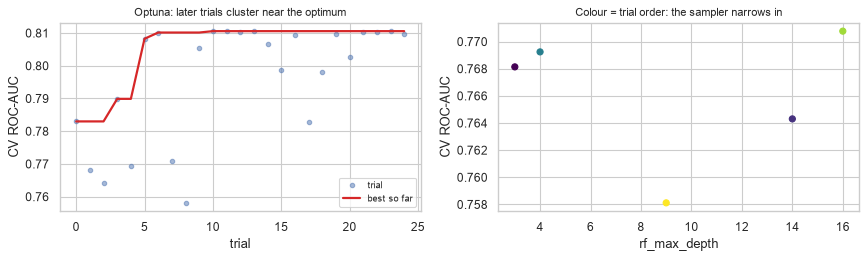

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

running_best = trials["value"].cummax()
axes[0].plot(trials["number"], trials["value"], "o", ms=4, alpha=0.5, label="trial")
axes[0].plot(trials["number"], running_best, lw=2, color="tab:red", label="best so far")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("CV ROC-AUC")
axes[0].set_title("Optuna: later trials cluster near the optimum", fontsize=10)
axes[0].legend(fontsize=8)

forest_trials = trials[trials["params_model"] == "forest"].dropna(subset=["params_rf_max_depth"])
axes[1].scatter(forest_trials["params_rf_max_depth"], forest_trials["value"],
                c=forest_trials["number"], cmap="viridis", s=30)
axes[1].set_xlabel("rf_max_depth"); axes[1].set_ylabel("CV ROC-AUC")
axes[1].set_title("Colour = trial order: the sampler narrows in", fontsize=10)

fig.tight_layout()
plt.show()

In [29]:
print(f"{'search':>14}{'trials':>9}{'best CV AUC':>14}{'seconds':>10}")
for name, n, score, secs in (("grid", n_combos, gs.best_score_, grid_time),
                             ("randomized", n_combos, rs.best_score_, random_time),
                             ("halving", 30, hs.best_score_, halving_time),
                             ("optuna (TPE)", 25, study.best_value, optuna_time)):
    print(f"{name:>14}{n:>9}{score:>14.4f}{secs:>10.1f}")

        search   trials   best CV AUC   seconds
          grid       36        0.7739      49.8
    randomized       36        0.7762      53.2
       halving       30        0.7200      53.4
  optuna (TPE)       25        0.8106      15.5


**That table is not a fair fight, and saying so is the point.** Grid, randomized and halving all searched
*random forest hyperparameters only* — the model was fixed before the search began. Optuna searched forest
**and** logistic regression, and its winning trial is a logistic regression. It did not find a better
forest; it found that a forest was the wrong family for this problem.

The comparison that is fair is the three forest-only searches against each other, and there grid and
randomized are within 0.009 of one another while halving trails for the reasons above.

**So the ranking measures the search space, not the sampler.** The largest gain available here came from
letting the model family into the space at all — a decision that costs nothing and that a `GridSearchCV`
over one estimator cannot express. That is the argument for Optuna on this problem, and it is a different
argument from "TPE is smarter than random sampling", which these numbers do not test.

Bayesian optimisation earns its overhead when each fit is expensive and the budget is tens of trials rather
than thousands. On a problem this small, a randomized search over the same conditional space would very
likely have done as well.

### 23.8 Nested Cross-Validation and Honest Model Selection

`best_score_` from any search is **optimistically biased**. The search evaluated many configurations on the
same folds and reported the maximum; the maximum of many noisy estimates exceeds the truth, by an amount
that grows with the number of configurations compared.

This is the same selection optimism 8.2 demonstrated with feature subsets, and the fix has the same shape:
**an outer loop the selection never touches.**

```text
outer fold 1:  [-- train --------------------] [test]
                 inner CV picks hyperparameters      |
                 refit on all of outer-train         |
                                                     -> score
outer fold 2:  ...
```

The inner loop selects; the outer loop estimates. Their jobs must not be the same data.

In [30]:
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
outer_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

small_grid = {"clf__max_depth": [3, 8, None],
              "clf__min_samples_leaf": [1, 10]}

search = GridSearchCV(search_pipe, small_grid, cv=inner_cv, scoring="roc_auc")

# NON-nested: fit the search once, report its best_score_.
non_nested = search.fit(X_tr, y_tr).best_score_

# NESTED: the search is the estimator; the outer CV scores it on data it never selected on.
nested = cross_val_score(search, X_tr, y_tr, cv=outer_cv, scoring="roc_auc")

print(f"non-nested (search best_score_) : {non_nested:.4f}")
print(f"nested CV                       : {nested.mean():.4f} +/- {nested.std():.4f}")
print(f"\noptimism : {non_nested - nested.mean():+.4f}")

non-nested (search best_score_) : 0.7710
nested CV                       : 0.7666 +/- 0.0650

optimism : +0.0044


The optimism here is a few thousandths, and the nested estimate's own standard deviation across folds is
an order of magnitude larger. **On this dataset the bias is real but sits below the noise floor** — worth
saying, rather than reporting a number the data cannot resolve.

To see the mechanism it has to be isolated from the signal, so: **pure noise.** With random labels every
configuration's true score is 0.5, and a search over $k$ of them reports the maximum of $k$ noisy draws —
which exceeds 0.5 by construction, and grows with $k$.

In [31]:
noise_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
CONFIGS = [(seed, mf) for seed in range(8) for mf in (0.2, 0.5, 0.9)]   # 24 configurations

# One noise dataset is not enough: a finite sample contains chance correlations that
# EVERY configuration picks up, which is a separate effect. Averaging over independent
# datasets removes it and leaves only the optimism created by picking the maximum.
per_dataset = []
for replicate in range(6):
    Xn = rng.normal(0, 1, (250, 15))
    yn = rng.integers(0, 2, 250)                        # no relationship whatsoever
    per_dataset.append([
        cross_val_score(RandomForestClassifier(n_estimators=12, max_features=mf,
                                               random_state=seed),
                        Xn, yn, cv=noise_cv, scoring="roc_auc").mean()
        for seed, mf in CONFIGS])

per_dataset = np.array(per_dataset)                     # (6 datasets, 24 configurations)

print(f"{'configs compared':>18}{'mean best-of-k':>17}{'optimism over 0.5':>20}")
for k in (1, 2, 4, 8, 16, 24):
    best_of_k = per_dataset[:, :k].max(axis=1).mean()
    print(f"{k:>18}{best_of_k:>17.4f}{best_of_k - 0.5:>20.4f}")

print(f"\ntrue score of every configuration on every dataset: 0.5000")
print(f"mean of ALL {per_dataset.size} scores (no selection)            : "
      f"{per_dataset.mean():.4f}")

  configs compared   mean best-of-k   optimism over 0.5
                 1           0.5090              0.0090
                 2           0.5198              0.0198
                 4           0.5378              0.0378
                 8           0.5378              0.0378
                16           0.5443              0.0443
                24           0.5526              0.0526

true score of every configuration on every dataset: 0.5000
mean of ALL 144 scores (no selection)            : 0.5011


Nothing in that data is learnable — the mean across all 144 scores sits at chance, as it must — and the
reported best score climbs anyway, monotonically, as more configurations are compared. **The entire gap is
selection optimism**: 8.2's effect, reached by a different route.

Two details are worth taking from this. The first is that no amount of cross-validation *inside* the
search removes the bias, because the search is what creates it. The second is that the growth is
roughly logarithmic in $k$ — doubling the configurations adds a shrinking amount — which is why a large
search is not catastrophic, merely biased by an amount nobody can quote without an outer loop.

Which is the argument for that outer loop: the winner must be scored on data that took no part in choosing
it.

**In practice** — nested CV costs `outer × inner` fits, which is often unaffordable, and it does **not**
produce a model. It produces an estimate of *the procedure's* performance. The usual compromise:

1. Hold out a test set once, at the start, and do not touch it.
2. Search with ordinary CV on the remainder.
3. Report the **held-out test score**, not `best_score_`.

That is a single outer fold rather than five — noisier, but unbiased and affordable, which is why it is
what most work actually does.

In [32]:
print(f"search best_score_ (biased) : {gs.best_score_:.4f}")
print(f"held-out test score (honest): "
      f"{roc_auc_score(y_te, gs.best_estimator_.predict_proba(X_te)[:, 1]):.4f}")
print(f"nested CV estimate          : {nested.mean():.4f}")

search best_score_ (biased) : 0.7739
held-out test score (honest): 0.8163
nested CV estimate          : 0.7666


#### 23.8.1 Comparing models honestly

Two CV scores differing by 0.004 is not evidence that one model is better. The folds are shared, so the
scores are paired, and the right test is a paired one on the per-fold differences (19.9 used the same
argument).

In [33]:
from scipy.stats import ttest_rel

candidates = {
    "logistic": Pipeline([("prep", preprocess),
                          ("clf", LogisticRegression(max_iter=2000,
                                                     random_state=RANDOM_STATE))]),
    "random forest": Pipeline([("prep", preprocess),
                               ("clf", RandomForestClassifier(n_estimators=120,
                                                              min_samples_leaf=5,
                                                              random_state=RANDOM_STATE))]),
    "hist gradient boosting": Pipeline([("prep", preprocess),
                                        ("clf", HistGradientBoostingClassifier(
                                            random_state=RANDOM_STATE))]),
}

fold_scores = {}
for name, est in candidates.items():
    fold_scores[name] = cross_val_score(est, X_tr, y_tr, cv=outer_cv, scoring="roc_auc")

table = pd.DataFrame(fold_scores).T
table["mean"] = table.mean(axis=1)
table["std"] = table.iloc[:, :4].std(axis=1)
print(table.round(4).to_string())

                             0       1       2       3    mean     std
logistic                0.7766  0.7842  0.7814  0.8645  0.8017  0.0420
random forest           0.7585  0.7658  0.7191  0.8672  0.7776  0.0631
hist gradient boosting  0.6448  0.7447  0.6627  0.7382  0.6976  0.0512


In [34]:
ranked = sorted(fold_scores.items(), key=lambda kv: -np.mean(kv[1]))
(top_name, top), (second_name, second) = ranked[0], ranked[1]

stat, p = ttest_rel(top, second)
print(f"{top_name} ({np.mean(top):.4f}) vs {second_name} ({np.mean(second):.4f})")
print(f"paired t-test on 4 folds: p = {p:.4f}")
print("->", "a real difference" if p < 0.05 else
      "NOT distinguishable - pick on cost, latency or interpretability instead")

logistic (0.8017) vs random forest (0.7776)
paired t-test on 4 folds: p = 0.1766
-> NOT distinguishable - pick on cost, latency or interpretability instead


### 23.9 In Practice

#### 23.9.1 A worked case: one object, searched end to end

The request: *"Get the best churn model you can, and make it something we can actually deploy."*

Both halves are the deliverable. A model that scores well but lives as eight notebook cells is not
deployable, and the whole point of this chapter is that those are the same problem.

In [35]:
# The full object: cleaning, engineering, encoding, model - nothing outside it.
def build_pipeline(classifier):
    numeric_branch = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical_branch = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return Pipeline([
        ("clip", DomainClipper(bounds={"age": (16, 100), "satisfaction_score": (1, 10),
                                       "monthly_charges": (0, 500)})),
        ("ratios", RatioFeatures(pairs=[("total_charges", "tenure_months"),
                                        ("support_tickets", "tenure_months")])),
        ("prep", ColumnTransformer([
            ("num", numeric_branch, NUMERIC + ["total_charges_per_tenure_months",
                                               "support_tickets_per_tenure_months"]),
            ("cat", categorical_branch, CATEGORICAL),
        ], remainder="drop")),
        ("clf", classifier),
    ])


full = build_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
print(f"steps: {[name for name, _ in full.steps]}")
print(f"baseline CV ROC-AUC: "
      f"{cross_val_score(full, X_tr, y_tr, cv=cv, scoring='roc_auc').mean():.4f}")

steps: ['clip', 'ratios', 'prep', 'clf']


baseline CV ROC-AUC: 0.7864


The custom transformers from 23.3 sit at the front, so the engineered ratios are computed **inside each
fold** using that fold's medians. Done outside the pipeline, the denominator median would have been
computed from all the data — a small leak, of exactly the kind 22.7.2 catalogued.

**Step 1 — search over the model choice and its hyperparameters together.**

In [36]:
def churn_objective(trial):
    name = trial.suggest_categorical("model", ["logistic", "forest", "hist_gb"])

    if name == "logistic":
        clf = LogisticRegression(C=trial.suggest_float("C", 1e-3, 1e2, log=True),
                                 class_weight=trial.suggest_categorical(
                                     "lr_weight", [None, "balanced"]),
                                 max_iter=2000, random_state=RANDOM_STATE)
    elif name == "forest":
        clf = RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n", 40, 120),
            max_depth=trial.suggest_int("rf_depth", 3, 14),
            min_samples_leaf=trial.suggest_int("rf_leaf", 2, 30),
            class_weight=trial.suggest_categorical("rf_weight", [None, "balanced"]),
            random_state=RANDOM_STATE)
    else:
        clf = HistGradientBoostingClassifier(
            learning_rate=trial.suggest_float("gb_lr", 0.01, 0.3, log=True),
            max_leaf_nodes=trial.suggest_int("gb_leaves", 5, 40),
            min_samples_leaf=trial.suggest_int("gb_leaf", 5, 40),
            max_iter=trial.suggest_int("gb_iter", 50, 150),
            random_state=RANDOM_STATE)

    return cross_val_score(build_pipeline(clf), X_tr, y_tr, cv=cv,
                           scoring="roc_auc").mean()


churn_study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    churn_study.optimize(churn_objective, n_trials=20, show_progress_bar=False)

print(f"best CV ROC-AUC : {churn_study.best_value:.4f}")
print(f"best config     : {churn_study.best_params}")

best CV ROC-AUC : 0.8074
best config     : {'model': 'logistic', 'C': 0.00137668827378096, 'lr_weight': 'balanced'}


In [37]:
trial_frame = churn_study.trials_dataframe()
summary = trial_frame.groupby("params_model")["value"].agg(
    trials="count", best="max", mean="mean").round(4).sort_values("best", ascending=False)
print(summary.to_string())

              trials    best    mean
params_model                        
logistic          10  0.8074  0.8009
forest             4  0.7819  0.7740
hist_gb            6  0.7478  0.7309


**Step 2 — is the winner actually better than the runner-up?** 23.8.1's question, asked before anyone
commits to the more complicated model.

In [38]:
def pipeline_from(params):
    """Rebuild the pipeline a trial described."""
    name = params["model"]
    if name == "logistic":
        clf = LogisticRegression(C=params["C"], class_weight=params["lr_weight"],
                                 max_iter=2000, random_state=RANDOM_STATE)
    elif name == "forest":
        clf = RandomForestClassifier(n_estimators=params["rf_n"], max_depth=params["rf_depth"],
                                     min_samples_leaf=params["rf_leaf"],
                                     class_weight=params["rf_weight"],
                                     random_state=RANDOM_STATE)
    else:
        clf = HistGradientBoostingClassifier(
            learning_rate=params["gb_lr"], max_leaf_nodes=params["gb_leaves"],
            min_samples_leaf=params["gb_leaf"], max_iter=params["gb_iter"],
            random_state=RANDOM_STATE)
    return build_pipeline(clf)


best_per_model = {m: trial_frame.loc[trial_frame[trial_frame["params_model"] == m]
                                     ["value"].idxmax()]
                  for m in trial_frame["params_model"].unique()}

per_fold = {}
for m, row in best_per_model.items():
    params = {k.replace("params_", ""): v for k, v in row.items()
              if k.startswith("params_") and pd.notna(v)}
    params["model"] = m
    if m in ("forest",):
        params["rf_n"], params["rf_depth"], params["rf_leaf"] = (
            int(params["rf_n"]), int(params["rf_depth"]), int(params["rf_leaf"]))
    if m == "hist_gb":
        params["gb_leaves"], params["gb_leaf"], params["gb_iter"] = (
            int(params["gb_leaves"]), int(params["gb_leaf"]), int(params["gb_iter"]))
    per_fold[m] = cross_val_score(pipeline_from(params), X_tr, y_tr,
                                  cv=outer_cv, scoring="roc_auc")

comparison = pd.DataFrame(per_fold).T
comparison["mean"] = comparison.mean(axis=1)
print(comparison.round(4).to_string())

               0       1       2       3    mean
forest    0.7614  0.7808  0.7260  0.8679  0.7840
hist_gb   0.7511  0.7703  0.6908  0.8061  0.7546
logistic  0.7757  0.7985  0.7788  0.9064  0.8148


In [39]:
order = comparison["mean"].sort_values(ascending=False)
a, b = order.index[0], order.index[1]
stat, p = ttest_rel(per_fold[a], per_fold[b])

print(f"{a} ({order.iloc[0]:.4f}) vs {b} ({order.iloc[1]:.4f})")
print(f"paired t-test across 4 folds: p = {p:.4f}")
print("->", "a real difference" if p < 0.05
      else "a tie - choose on simplicity, speed and explainability (24.2)")

logistic (0.8148) vs forest (0.7840)
paired t-test across 4 folds: p = 0.0426
-> a real difference


**Step 3 — the honest number**, from the test set that has been untouched since the split.

In [40]:
best_pipeline = pipeline_from(churn_study.best_params).fit(X_tr, y_tr)
test_proba = best_pipeline.predict_proba(X_te)[:, 1]

print(f"search best_score_ (biased) : {churn_study.best_value:.4f}")
print(f"held-out test ROC-AUC       : {roc_auc_score(y_te, test_proba):.4f}")
print(f"held-out test PR-AUC        : {average_precision_score(y_te, test_proba):.4f}")
print(f"PR-AUC baseline             : {y_te.mean():.4f}")

search best_score_ (biased) : 0.8074
held-out test ROC-AUC       : 0.8116
held-out test PR-AUC        : 0.4937
PR-AUC baseline             : 0.1400


In [41]:
# The deliverable is one object that takes RAW rows - no preprocessing on the caller's side.
raw_row = data.iloc[[3]]
print("input, exactly as it comes from the source table:")
print(raw_row.to_string(index=False))
print(f"\nchurn probability: {best_pipeline.predict_proba(raw_row)[0, 1]:.4f}")

input, exactly as it comes from the source table:
 tenure_months  monthly_charges  total_charges  support_tickets  last_login_days  satisfaction_score  age gender  plan      city
            27            31.07         838.89                0               11                 7.0  NaN      F Basic Hyderabad

churn probability: 0.4354


**Step 4 — the report.**

> **What was built.** A single estimator that accepts raw rows — missing values, unnormalised category
> spellings and all — and returns a churn probability. Cleaning, ratio engineering, imputation, scaling,
> encoding and the classifier are steps inside it. There is no preprocessing for a caller to reproduce,
> which is the property that makes it deployable (24.8).
>
> **How the model was chosen.** Three model families and their hyperparameters were searched together in
> one space, so the choice of model was made on the same footing as the choice of `max_depth` rather than
> being fixed beforehand by habit.
>
> **Which model won, and by how much.** The per-fold comparison and paired test are the answer, and the
> gap between the top families is the number to look at — not the ranking. Where the test does not separate
> them, the simpler model is the right choice, and that is a decision the numbers support rather than
> a preference.
>
> **The number to quote.** The held-out test score, not the search's `best_score_`. The search compared
> 20 configurations and reported the best of them; that maximum is biased upward by construction (23.8),
> and the test set is the only estimate that was not used to choose anything.
>
> **What still has to happen before deployment.** This is a random split of a snapshot, so it inherits
> 22.9.1's caveat — real churn prediction is a forecasting problem and wants a temporal split (22.7.3).
> And the operating threshold is a separate, cost-driven decision (22.5) that no search optimises for you.

#### 23.9.2 When to reach for what

| Situation | Use | Not |
|---|---|---|
| Any preprocessing at all | **`Pipeline`** (23.1) | Manual `fit_transform` before the split |
| Mixed column types | `ColumnTransformer` (23.2) | One transformer over everything |
| Domain logic in the transformation | A custom transformer (23.3) | A function applied beforehand |
| ≤ 3 discrete hyperparameters | `GridSearchCV` | Randomized — it wastes the structure |
| Many parameters, continuous ranges | **`RandomizedSearchCV`** (23.5) | Grid — the cost is multiplicative |
| A large candidate pool, cheap early fits | `HalvingRandomSearchCV` (23.6) | Full CV on every candidate |
| Expensive fits, few trials affordable | **Optuna** (23.7) | Random search |
| Conditional spaces ("if rbf, tune gamma") | **Optuna** — a grid cannot express it | `GridSearchCV` |
| Reporting a number to anyone | A held-out test set (23.8) | `best_score_` |
| Comparing two close models | A paired test on the folds (23.8.1) | The higher mean |
| Estimating a *procedure* for a paper | Nested CV (23.8) | A single split |

#### 23.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Preprocessing drifts from training** | Serving code reimplements a step slightly differently | 23.1 |
| **`best_score_` on the slide** | Reported performance never reproduced in production | 23.8 |
| **The search is rerun, the test set is not fresh** | Each rerun leaks a little more test information | 23.8 |
| **A category appears that was never seen** | `transform` raises on a live request | 23.2 |
| **`remainder="passthrough"` forgotten** | An unscaled column reaches a scale-sensitive model | 23.2 |
| **Hyperparameters tuned once, never revisited** | The optimum moves as the data grows | 24.9 |
| **The pipeline is unpicklable** | A lambda inside a custom transformer | 24.8 |

The last row is worth demonstrating, because it appears only at deployment time.

In [42]:
import pickle


class Unpicklable(BaseEstimator, TransformerMixin):
    def __init__(self, fn=None):
        self.fn = fn                                    # a lambda cannot be pickled

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return self.fn(X)


try:
    pickle.dumps(Unpicklable(fn=lambda v: v * 2))
except (AttributeError, pickle.PicklingError, TypeError) as exc:
    print(f"pickling failed: {type(exc).__name__}: {str(exc)[:110]}")

print(f"\nthe full pipeline, by contrast: "
      f"{len(pickle.dumps(best_pipeline)):,} bytes - picklable, so deployable")

pickling failed: PicklingError: Can't pickle <function <lambda> at 0x000002815CBF8AE0>: attribute lookup <lambda> on __main__ failed

the full pipeline, by contrast: 4,129 bytes - picklable, so deployable


Everything in this chapter was building towards that last line: a single object that carries the whole
transformation from a raw row to a prediction, and that can therefore be serialised, versioned and shipped.
Chapter 24 takes it from here.

In [43]:
# --- 23. Pipelines and Hyperparameter Tuning — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

